# Milestone 3

In [2]:
import sys
sys.path.insert(0, "..")
import ccs_eeg_utils
from mne_bids import (BIDSPath, read_raw_bids)
import mne

bids_root = "../MNE-sample-data/ds006761"
subject_id = "01"

#print_dir_tree(bids_root, max_depth=4)

bids_path = BIDSPath(subject=subject_id, task="RPS",
                     datatype='eeg', suffix='eeg',
                     root=bids_root)

# read the file
raw = read_raw_bids(bids_path)
# fix the annotations readin
ccs_eeg_utils.read_annotations_core(bids_path,raw)


Extracting BDF parameters from ..\MNE-sample-data\ds006761\sub-01\eeg\sub-01_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading events from ..\MNE-sample-data\ds006761\sub-01\eeg\sub-01_task-RPS_events.tsv.


C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6380\3105469879.py:17: RuntimeWarning: Did not find any channels.tsv associated with sub-01_task-RPS.

The search_str was "..\MNE-sample-data\ds006761\sub-01\**\eeg\sub-01*channels.tsv"
  raw = read_raw_bids(bids_path)
C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6380\3105469879.py:17: RuntimeWarning: Unable to map the following column(s) to to MNE:
date: 9/11/2021
player1_age: 25
player1_gender: F
player1_handedness: R
player1_pre_processing_channels_fixed: 
player2_age: 35
player2_gender: M
player2_handedness: R
player2_pre_processing_channels_fixed: T8
  raw = read_raw_bids(bids_path)


In [3]:
eeg_channels = [ch for ch in raw.ch_names]
eeg_channels

['1-A1',
 '1-A2',
 '1-A3',
 '1-A4',
 '1-A5',
 '1-A6',
 '1-A7',
 '1-A8',
 '1-A9',
 '1-A10',
 '1-A11',
 '1-A12',
 '1-A13',
 '1-A14',
 '1-A15',
 '1-A16',
 '1-A17',
 '1-A18',
 '1-A19',
 '1-A20',
 '1-A21',
 '1-A22',
 '1-A23',
 '1-A24',
 '1-A25',
 '1-A26',
 '1-A27',
 '1-A28',
 '1-A29',
 '1-A30',
 '1-A31',
 '1-A32',
 '1-B1',
 '1-B2',
 '1-B3',
 '1-B4',
 '1-B5',
 '1-B6',
 '1-B7',
 '1-B8',
 '1-B9',
 '1-B10',
 '1-B11',
 '1-B12',
 '1-B13',
 '1-B14',
 '1-B15',
 '1-B16',
 '1-B17',
 '1-B18',
 '1-B19',
 '1-B20',
 '1-B21',
 '1-B22',
 '1-B23',
 '1-B24',
 '1-B25',
 '1-B26',
 '1-B27',
 '1-B28',
 '1-B29',
 '1-B30',
 '1-B31',
 '1-B32',
 '1-GSR1',
 '1-GSR2',
 '1-Erg1',
 '1-Erg2',
 '1-Resp',
 '1-Plet',
 '1-Temp',
 '2-A1',
 '2-A2',
 '2-A3',
 '2-A4',
 '2-A5',
 '2-A6',
 '2-A7',
 '2-A8',
 '2-A9',
 '2-A10',
 '2-A11',
 '2-A12',
 '2-A13',
 '2-A14',
 '2-A15',
 '2-A16',
 '2-A17',
 '2-A18',
 '2-A19',
 '2-A20',
 '2-A21',
 '2-A22',
 '2-A23',
 '2-A24',
 '2-A25',
 '2-A26',
 '2-A27',
 '2-A28',
 '2-A29',
 '2-A30',
 '2-A31',


In [4]:
# --- 1. Kanaltypen setzen ---
eeg_channels = [ch for ch in raw.ch_names if (ch.startswith("1-A") or ch.startswith("1-B") or
                                              ch.startswith("2-A") or ch.startswith("2-B"))]
eog_channels = ['1-Erg1', '1-Erg2', '2-Erg1', '2-Erg2']
resp_channels = ['1-Resp', '2-Resp']
bio_channels = ['1-Plet', '2-Plet']
temp_channels = ['1-Temp', '2-Temp']
stim_channels = ['Status']

raw.set_channel_types({ch: 'eeg' for ch in eeg_channels})
raw.set_channel_types({ch: 'eog' for ch in eog_channels})
raw.set_channel_types({ch: 'resp' for ch in resp_channels})
raw.set_channel_types({ch: 'bio' for ch in bio_channels})
raw.set_channel_types({ch: 'temperature' for ch in temp_channels})
raw.set_channel_types({ch: 'stim' for ch in stim_channels})

C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6380\692441371.py:14: RuntimeWarning: The unit for channel(s) 1-Temp, 2-Temp has changed from V to C.
  raw.set_channel_types({ch: 'temperature' for ch in temp_channels})
C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6380\692441371.py:15: RuntimeWarning: The unit for channel(s) Status has changed from NA to V.
  raw.set_channel_types({ch: 'stim' for ch in stim_channels})


<RawBDF | sub-01_task-RPS_eeg.bdf, 143 x 7514112 (3669.0 s), ~113 KiB, data not loaded>

In [5]:
%matplotlib ipympl
mne.viz.set_browser_backend('matplotlib')

Using matplotlib as 2D backend.


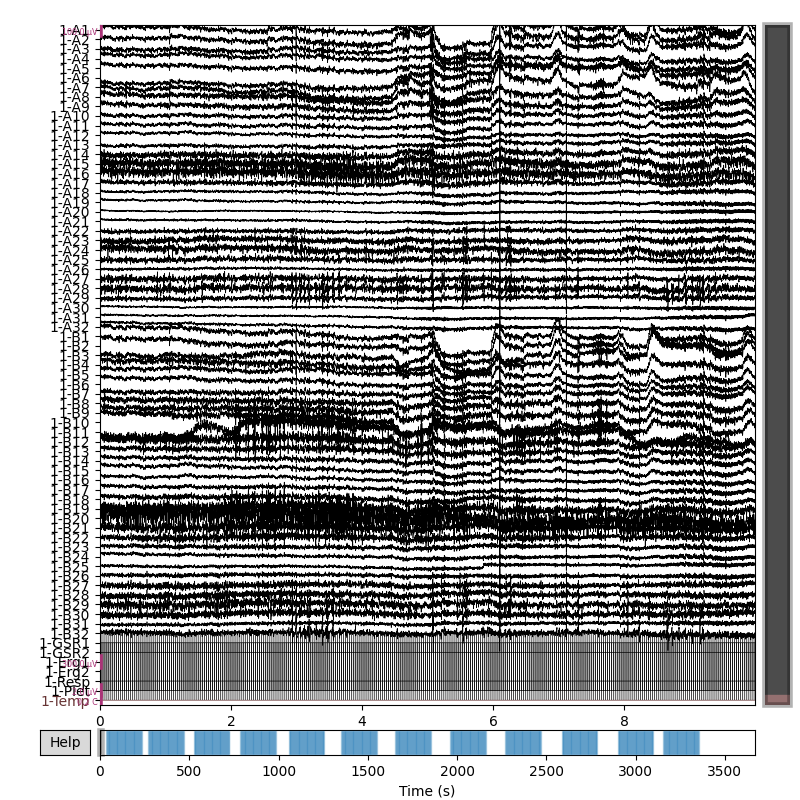

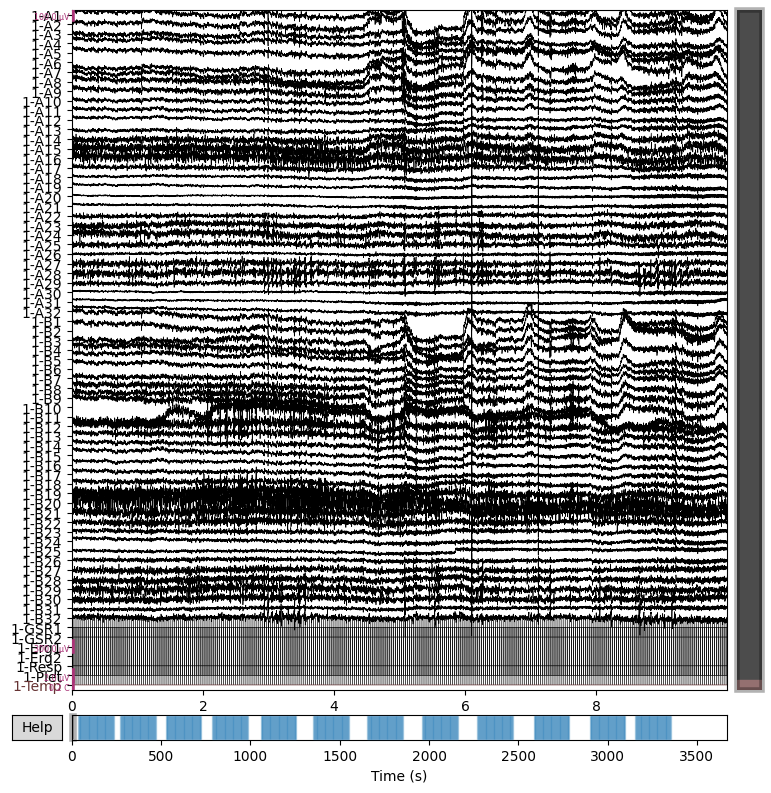

In [6]:
person1_channels = [ch for ch in raw.ch_names if ch.startswith("1-")]

raw.plot(
    picks=person1_channels,
    scalings={'eeg': 50e-6},
    block=True,            # blockiert Jupyter, zeigt ganze Figur
    show_options=False,    # keine Overlay-Menüs
    n_channels=len(person1_channels),  # alle Kanäle gleichzeitig

)


In [5]:
import pandas as pd
import os

# Use your existing path
bids_root = "../MNE-sample-data/ds006761"
subject_id = "01"

# Find the events file
events_file = os.path.join(bids_root, f"sub-{subject_id}", "eeg", 
                           f"sub-{subject_id}_task-RPS_events.tsv")

print(f"Looking for: {events_file}")
print(f"File exists: {os.path.exists(events_file)}")

if os.path.exists(events_file):
    events_df = pd.read_csv(events_file, sep='\t')
    print("\nColumns:", events_df.columns.tolist())
    print("\nFirst 10 rows:")
    print(events_df.head(10))
else:
    # List what files are actually there
    eeg_folder = os.path.join(bids_root, f"sub-{subject_id}", "eeg")
    print("\nFiles in eeg folder:")
    print(os.listdir(eeg_folder))

Looking for: ../MNE-sample-data/ds006761\sub-01\eeg\sub-01_task-RPS_events.tsv
File exists: True

Columns: ['onset', 'duration', 'onset_sample', 'trial_num', 'player1_resp', 'player1_rt', 'player2_resp', 'player2_rt', 'outcome']

First 10 rows:
       onset  duration  onset_sample  trial_num  player1_resp  player1_rt  \
0  32.777344         5         67128          1             3       0.558   
1  37.769043         5         77351          2             3       0.435   
2  42.760742         5         87574          3             2       0.643   
3  47.760254         5         97813          4             2       0.717   
4  52.760254         5        108053          5             1       0.642   
5  57.760254         5        118293          6             1       0.752   
6  62.751953         5        128516          7             2       0.634   
7  67.751465         5        138755          8             3       0.769   
8  72.751465         5        148995          9             3 

In [7]:
import pandas as pd
import numpy as np

# Load the events
bids_root = "../MNE-sample-data/ds006761"
subject_id = "01"
events_file = f"{bids_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-RPS_events.tsv"
events_df = pd.read_csv(events_file, sep='\t')

# Convert choices to 0-indexed (0=Rock, 1=Paper, 2=Scissors)
player1_choices = (events_df['player1_resp'] - 1).tolist()
player2_choices = (events_df['player2_resp'] - 1).tolist()

# Convert outcomes to win/loss for each player
# outcome: 1=draw, 2=player1 wins, 3=player2 wins
outcomes = events_df['outcome'].tolist()
player1_outcomes = [0 if o == 1 else (1 if o == 2 else -1) for o in outcomes]  # 1=win, 0=draw, -1=loss
player2_outcomes = [0 if o == 1 else (1 if o == 3 else -1) for o in outcomes]

# Markov analysis functions
def compute_markov_transition_matrix(choices):
    counts = np.zeros((3, 3))
    for i in range(len(choices) - 1):
        counts[choices[i], choices[i + 1]] += 1
    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return counts / row_sums

def compute_predictability(matrix):
    max_entropy = np.log2(3)
    entropies = []
    for row in matrix:
        if row.sum() > 0:
            row = row[row > 0]
            entropies.append(-np.sum(row * np.log2(row)))
    avg_entropy = np.mean(entropies) if entropies else max_entropy
    return 1 - (avg_entropy / max_entropy)

def classify_strategy(choices, outcomes):
    win_stay = lose_shift = win_opp = lose_opp = 0
    for i in range(len(choices) - 1):
        if outcomes[i] == 1:  # Won
            win_opp += 1
            if choices[i + 1] == choices[i]:
                win_stay += 1
        elif outcomes[i] == -1:  # Lost
            lose_opp += 1
            if choices[i + 1] != choices[i]:
                lose_shift += 1
    return {
        'win_stay_rate': win_stay / win_opp if win_opp > 0 else 0,
        'lose_shift_rate': lose_shift / lose_opp if lose_opp > 0 else 0
    }

# Analyze Player 1
print("=" * 50)
print("PLAYER 1 ANALYSIS")
print("=" * 50)
matrix1 = compute_markov_transition_matrix(player1_choices)
print("\nTransition Matrix (rows=current, cols=next):")
print("         Rock    Paper   Scissors")
for i, label in enumerate(['Rock    ', 'Paper   ', 'Scissors']):
    print(f"{label} {matrix1[i]}")
print(f"\nPredictability: {compute_predictability(matrix1):.3f} (0=random, 1=predictable)")
strat1 = classify_strategy(player1_choices, player1_outcomes)
print(f"Win-Stay Rate: {strat1['win_stay_rate']:.2%}")
print(f"Lose-Shift Rate: {strat1['lose_shift_rate']:.2%}")

# Analyze Player 2
print("\n" + "=" * 50)
print("PLAYER 2 ANALYSIS")
print("=" * 50)
matrix2 = compute_markov_transition_matrix(player2_choices)
print("\nTransition Matrix (rows=current, cols=next):")
print("         Rock    Paper   Scissors")
for i, label in enumerate(['Rock    ', 'Paper   ', 'Scissors']):
    print(f"{label} {matrix2[i]}")
print(f"\nPredictability: {compute_predictability(matrix2):.3f} (0=random, 1=predictable)")
strat2 = classify_strategy(player2_choices, player2_outcomes)
print(f"Win-Stay Rate: {strat2['win_stay_rate']:.2%}")
print(f"Lose-Shift Rate: {strat2['lose_shift_rate']:.2%}")

# Summary
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"Total trials: {len(events_df)}")
print(f"Player 1 wins: {outcomes.count(2)} ({outcomes.count(2)/len(outcomes):.1%})")
print(f"Player 2 wins: {outcomes.count(3)} ({outcomes.count(3)/len(outcomes):.1%})")
print(f"Draws: {outcomes.count(1)} ({outcomes.count(1)/len(outcomes):.1%})")

PLAYER 1 ANALYSIS

Transition Matrix (rows=current, cols=next):
         Rock    Paper   Scissors
Rock     [0.43859649 0.25730994 0.30409357]
Paper    [0.28767123 0.42465753 0.28767123]
Scissors [0.33950617 0.24691358 0.41358025]

Predictability: 0.020 (0=random, 1=predictable)
Win-Stay Rate: 39.38%
Lose-Shift Rate: 55.86%

PLAYER 2 ANALYSIS

Transition Matrix (rows=current, cols=next):
         Rock    Paper   Scissors
Rock     [0.32317073 0.29268293 0.38414634]
Paper    [0.3125 0.3375 0.35  ]
Scissors [0.39354839 0.36774194 0.23870968]

Predictability: 0.009 (0=random, 1=predictable)
Win-Stay Rate: 22.07%
Lose-Shift Rate: 80.62%

SUMMARY
Total trials: 480
Player 1 wins: 161 (33.5%)
Player 2 wins: 145 (30.2%)
Draws: 174 (36.2%)


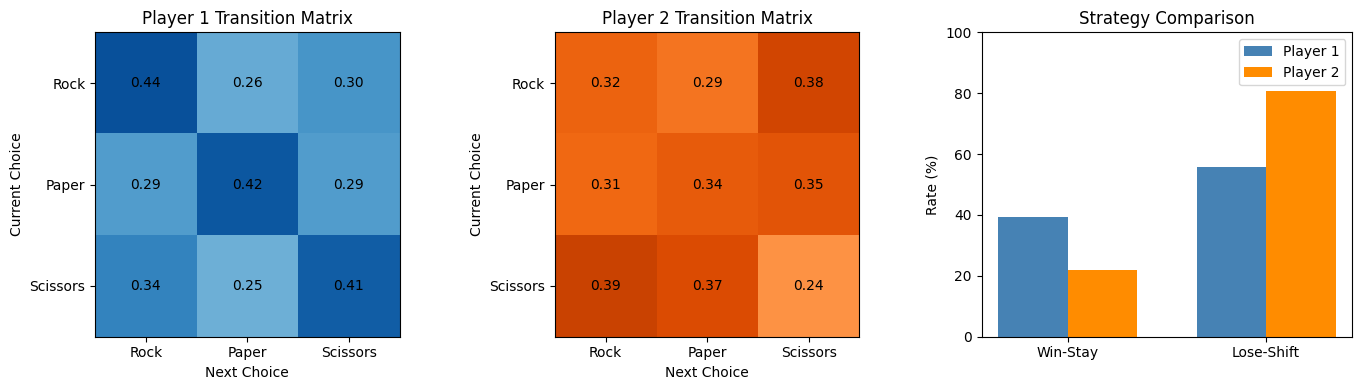


Task 1 (Predictability Measure) complete!


In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Transition matrices as heatmaps
labels = ['Rock', 'Paper', 'Scissors']

ax1 = axes[0]
im1 = ax1.imshow(matrix1, cmap='Blues', vmin=0, vmax=0.5)
ax1.set_xticks([0, 1, 2])
ax1.set_yticks([0, 1, 2])
ax1.set_xticklabels(labels)
ax1.set_yticklabels(labels)
ax1.set_xlabel('Next Choice')
ax1.set_ylabel('Current Choice')
ax1.set_title('Player 1 Transition Matrix')
for i in range(3):
    for j in range(3):
        ax1.text(j, i, f'{matrix1[i,j]:.2f}', ha='center', va='center')

ax2 = axes[1]
im2 = ax2.imshow(matrix2, cmap='Oranges', vmin=0, vmax=0.5)
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2])
ax2.set_xticklabels(labels)
ax2.set_yticklabels(labels)
ax2.set_xlabel('Next Choice')
ax2.set_ylabel('Current Choice')
ax2.set_title('Player 2 Transition Matrix')
for i in range(3):
    for j in range(3):
        ax2.text(j, i, f'{matrix2[i,j]:.2f}', ha='center', va='center')

# Plot 2: Strategy comparison
ax3 = axes[2]
x = np.arange(2)
width = 0.35
bars1 = ax3.bar(x - width/2, [strat1['win_stay_rate']*100, strat1['lose_shift_rate']*100], 
                width, label='Player 1', color='steelblue')
bars2 = ax3.bar(x + width/2, [strat2['win_stay_rate']*100, strat2['lose_shift_rate']*100], 
                width, label='Player 2', color='darkorange')
ax3.set_ylabel('Rate (%)')
ax3.set_title('Strategy Comparison')
ax3.set_xticks(x)
ax3.set_xticklabels(['Win-Stay', 'Lose-Shift'])
ax3.legend()
ax3.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\nTask 1 (Predictability Measure) complete!")

In [9]:
def detect_cycling(choices):
    """
    Detect cycling patterns: R->P->S->R (forward) or R->S->P->R (backward)
    """
    forward_cycle = 0   # R->P->S->R (0->1->2->0)
    backward_cycle = 0  # R->S->P->R (0->2->1->0)
    total_transitions = len(choices) - 1
    
    for i in range(len(choices) - 1):
        current = choices[i]
        next_choice = choices[i + 1]
        
        # Forward: Rock->Paper, Paper->Scissors, Scissors->Rock
        if (current + 1) % 3 == next_choice:
            forward_cycle += 1
        # Backward: Rock->Scissors, Scissors->Paper, Paper->Rock
        elif (current - 1) % 3 == next_choice:
            backward_cycle += 1
    
    return {
        'forward_cycle_rate': forward_cycle / total_transitions,
        'backward_cycle_rate': backward_cycle / total_transitions,
        'total_cycle_rate': (forward_cycle + backward_cycle) / total_transitions,
        'random_expected': 2/3  # If random, 2 of 3 transitions would be "cycling"
    }

# Analyze cycling for both players
print("CYCLING ANALYSIS")
print("=" * 50)

cycle1 = detect_cycling(player1_choices)
print(f"\nPlayer 1:")
print(f"  Forward cycling (R→P→S→R):  {cycle1['forward_cycle_rate']:.2%}")
print(f"  Backward cycling (R→S→P→R): {cycle1['backward_cycle_rate']:.2%}")
print(f"  Total cycling rate:          {cycle1['total_cycle_rate']:.2%}")

cycle2 = detect_cycling(player2_choices)
print(f"\nPlayer 2:")
print(f"  Forward cycling (R→P→S→R):  {cycle2['forward_cycle_rate']:.2%}")
print(f"  Backward cycling (R→S→P→R): {cycle2['backward_cycle_rate']:.2%}")
print(f"  Total cycling rate:          {cycle2['total_cycle_rate']:.2%}")

print(f"\nExpected if random: {cycle1['random_expected']:.2%}")
print("\nNote: If cycling rate ≈ 66%, player is random.")
print("      If cycling rate > 66%, player tends to cycle.")
print("      If cycling rate < 66%, player tends to repeat.")

CYCLING ANALYSIS

Player 1:
  Forward cycling (R→P→S→R):  29.44%
  Backward cycling (R→S→P→R): 27.97%
  Total cycling rate:          57.41%

Player 2:
  Forward cycling (R→P→S→R):  34.03%
  Backward cycling (R→S→P→R): 35.49%
  Total cycling rate:          69.52%

Expected if random: 66.67%

Note: If cycling rate ≈ 66%, player is random.
      If cycling rate > 66%, player tends to cycle.
      If cycling rate < 66%, player tends to repeat.


In [10]:
# PLACEHOLDER - use when teammates provide synchrony data
def correlate_with_neural(predictability_scores, synchrony_scores):
    """
    Correlate behavioral predictability with neural synchrony
    """
    from scipy.stats import pearsonr, spearmanr
    
    r_pearson, p_pearson = pearsonr(predictability_scores, synchrony_scores)
    r_spearman, p_spearman = spearmanr(predictability_scores, synchrony_scores)
    
    return {
        'pearson_r': r_pearson,
        'pearson_p': p_pearson,
        'spearman_r': r_spearman,
        'spearman_p': p_spearman
    }

# Example usage (when you have the data):
# result = correlate_with_neural(predictability_per_trial, synchrony_per_trial)
# print(f"Correlation: r={result['pearson_r']:.3f}, p={result['pearson_p']:.4f}")

In [11]:
# TASK II SUMMARY - Behavioral Analysis
behavioral_results = {
    'player1': {
        'predictability': compute_predictability(matrix1),
        'win_stay_rate': strat1['win_stay_rate'],
        'lose_shift_rate': strat1['lose_shift_rate'],
        'cycling_rate': cycle1['total_cycle_rate'],
        'transition_matrix': matrix1
    },
    'player2': {
        'predictability': compute_predictability(matrix2),
        'win_stay_rate': strat2['win_stay_rate'],
        'lose_shift_rate': strat2['lose_shift_rate'],
        'cycling_rate': cycle2['total_cycle_rate'],
        'transition_matrix': matrix2
    }
}

print("Behavioral results saved to 'behavioral_results' dictionary")
print("Ready for correlation with neural data from teammates")

Behavioral results saved to 'behavioral_results' dictionary
Ready for correlation with neural data from teammates


In [14]:
import mne
import numpy as np
import pandas as pd

# Load events from TSV file
bids_root = "../MNE-sample-data/ds006761"
subject_id = "01"
events_file = f"{bids_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-RPS_events.tsv"
events_df = pd.read_csv(events_file, sep='\t')

# Create MNE events array from onset_sample
# Format: [sample, 0, event_id]
# We'll use player1 response as event (1=Rock, 2=Paper, 3=Scissors)
events_array = np.column_stack([
    events_df['onset_sample'].values,
    np.zeros(len(events_df), dtype=int),
    events_df['player1_resp'].values
])

event_id = {'Rock': 1, 'Paper': 2, 'Scissors': 3}

print(f"Created {len(events_array)} events")
print(f"Event IDs: {event_id}")

# Create epochs
# tmin = before stimulus, tmax = after stimulus
epochs = mne.Epochs(
    raw, 
    events=events_array, 
    event_id=event_id,
    tmin=-0.5,  # 500ms before
    tmax=1.5,   # 1500ms after
    baseline=(-0.5, 0),  # Baseline correction
    preload=True,
    reject=None,  # No rejection for now
    verbose=True
)

print(f"\nEpochs created: {epochs}")
print(f"Number of epochs: {len(epochs)}")
print(f"Time range: {epochs.tmin} to {epochs.tmax} seconds")
print(f"Channels: {len(epochs.ch_names)}")

Created 480 events
Event IDs: {'Rock': 1, 'Paper': 2, 'Scissors': 3}
Not setting metadata
480 matching events found
Applying baseline correction (mode: mean)


0 projection items activated
Loading data for 480 events and 4097 original time points ...
0 bad epochs dropped

Epochs created: <Epochs | 480 events (all good), -0.5 – 1.5 s (baseline -0.5 – 0 s), ~2.10 GiB, data loaded,
 'Rock': 172
 'Paper': 146
 'Scissors': 162>
Number of epochs: 480
Time range: -0.5 to 1.5 seconds
Channels: 143


In [16]:
import mne
import numpy as np

# Pick only a few key channels to speed up
key_channels = ['Fz', 'Cz', 'Pz', 'Oz', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4']

# Find which channels exist in our data
available_channels = [ch for ch in key_channels if ch in epochs.ch_names]
print(f"Using channels: {available_channels}")

# If none found, use first 10 EEG channels
if not available_channels:
    available_channels = epochs.ch_names[:10]
    print(f"Key channels not found. Using: {available_channels}")

# Pick subset of channels
epochs_subset = epochs.copy().pick_channels(available_channels)

# Downsample to speed up (if sampling rate is high)
print(f"Original sampling rate: {epochs_subset.info['sfreq']} Hz")
if epochs_subset.info['sfreq'] > 256:
    epochs_subset = epochs_subset.resample(256)
    print(f"Resampled to: {epochs_subset.info['sfreq']} Hz")

# Fewer frequencies
freqs = np.arange(4, 41, 4)  # 4, 8, 12, ... 40 Hz (fewer steps)
n_cycles = freqs / 2

print(f"\nAnalyzing {len(freqs)} frequencies: {freqs}")
print(f"Epochs: {len(epochs_subset)}, Channels: {len(epochs_subset.ch_names)}")
print("Computing time-frequency...")

# Compute TFR
power = mne.time_frequency.tfr_morlet(
    epochs_subset,
    freqs=freqs,
    n_cycles=n_cycles,
    return_itc=False,
    average=True,
    n_jobs=1,
    verbose=True
)

print("Done!")
print(f"Power shape: {power.data.shape}")

Using channels: []
Key channels not found. Using: ['1-A1', '1-A2', '1-A3', '1-A4', '1-A5', '1-A6', '1-A7', '1-A8', '1-A9', '1-A10']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Original sampling rate: 2048.0 Hz
Resampled to: 256.0 Hz

Analyzing 10 frequencies: [ 4  8 12 16 20 24 28 32 36 40]
Epochs: 480, Channels: 10
Computing time-frequency...
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Done!
Power shape: (10, 10, 512)


Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


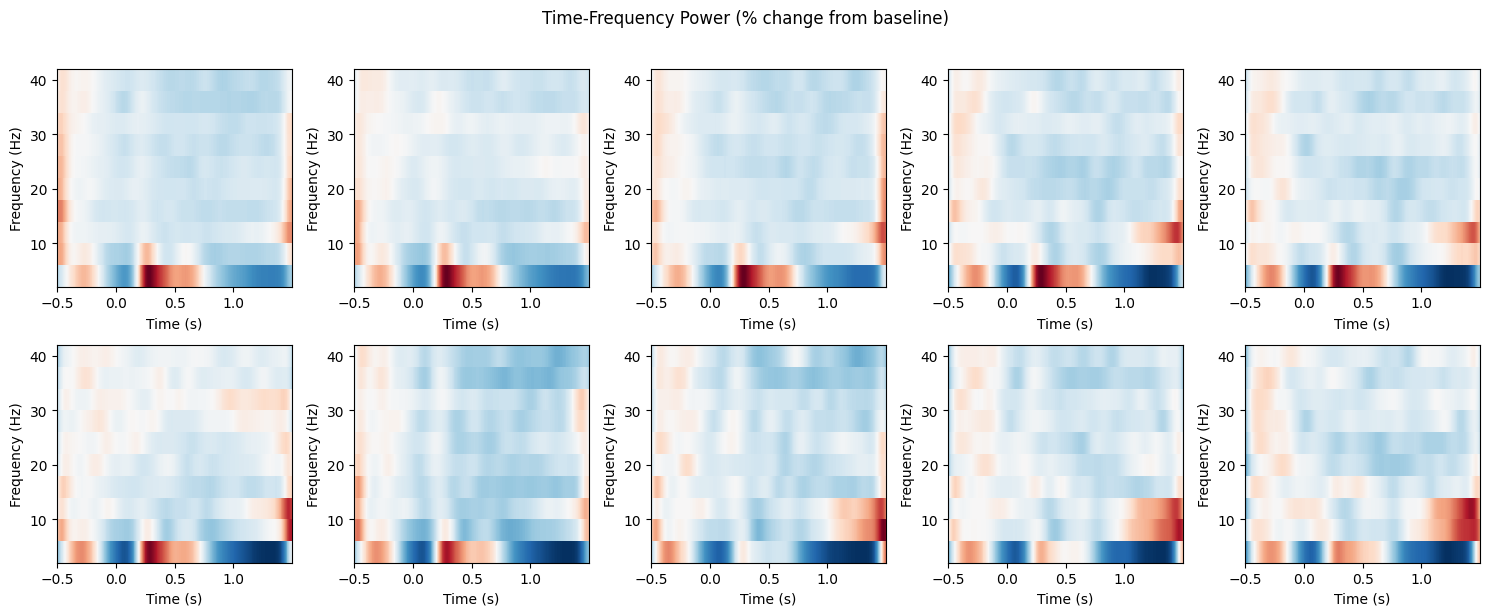

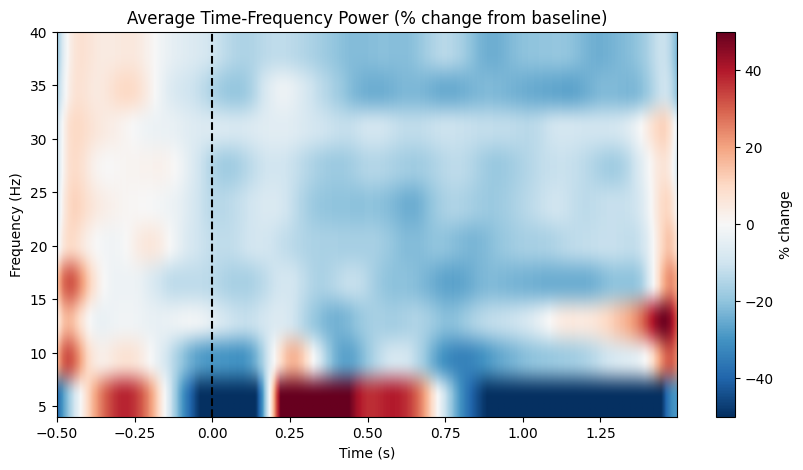

Time-frequency plots complete!


In [17]:
import matplotlib.pyplot as plt

# Plot time-frequency for each channel
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ch_name in enumerate(power.ch_names):
    power.plot(
        picks=[ch_name],
        baseline=(-0.5, 0),
        mode='percent',
        axes=axes[i],
        show=False,
        colorbar=False,
        title=ch_name
    )

plt.tight_layout()
plt.suptitle('Time-Frequency Power (% change from baseline)', y=1.02)
plt.show()

# Plot average across all channels
fig2, ax2 = plt.subplots(figsize=(10, 5))
power_avg = power.data.mean(axis=0)  # Average across channels

# Apply baseline correction manually for plotting
baseline_mask = power.times < 0
baseline_power = power_avg[:, baseline_mask].mean(axis=1, keepdims=True)
power_pct = (power_avg - baseline_power) / baseline_power * 100

im = ax2.imshow(
    power_pct,
    aspect='auto',
    origin='lower',
    extent=[power.times[0], power.times[-1], freqs[0], freqs[-1]],
    cmap='RdBu_r',
    vmin=-50, vmax=50
)
ax2.axvline(0, color='k', linestyle='--', label='Stimulus')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Frequency (Hz)')
ax2.set_title('Average Time-Frequency Power (% change from baseline)')
plt.colorbar(im, ax=ax2, label='% change')
plt.show()

print("Time-frequency plots complete!")

Computing time-frequency for each condition...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Rock: 172 epochs
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Paper: 146 epochs
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Scissors: 162 epochs
Done!


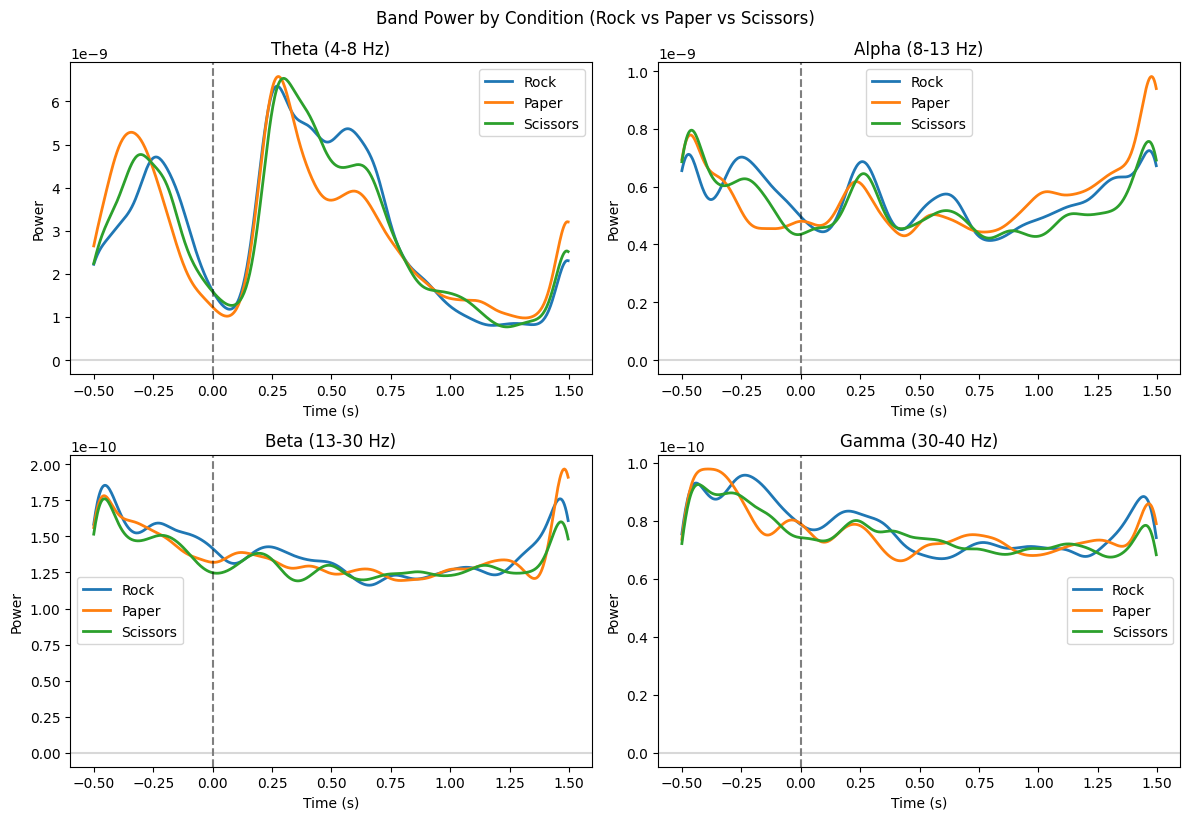


Time-Frequency Analysis complete!


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Define frequency bands
bands = {
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 40)
}

# Compute TFR for each condition separately
conditions = ['Rock', 'Paper', 'Scissors']
power_by_condition = {}

print("Computing time-frequency for each condition...")
for cond in conditions:
    epochs_cond = epochs.copy().pick_channels(available_channels)
    epochs_cond = epochs_cond.resample(256)
    epochs_cond = epochs_cond[cond]  # Select only this condition
    
    tfr = mne.time_frequency.tfr_morlet(
        epochs_cond,
        freqs=freqs,
        n_cycles=freqs/2,
        return_itc=False,
        average=True,
        verbose=False
    )
    power_by_condition[cond] = tfr
    print(f"  {cond}: {len(epochs_cond)} epochs")

print("Done!")

# Extract band power over time for each condition
def get_band_power(tfr, band_range):
    """Extract average power in a frequency band"""
    freq_mask = (tfr.freqs >= band_range[0]) & (tfr.freqs <= band_range[1])
    # Average across channels and frequencies in band
    band_power = tfr.data[:, freq_mask, :].mean(axis=(0, 1))
    return band_power

# Plot band power over time for each condition
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

times = power_by_condition['Rock'].times

for i, (band_name, band_range) in enumerate(bands.items()):
    ax = axes[i]
    
    for cond in conditions:
        band_power = get_band_power(power_by_condition[cond], band_range)
        ax.plot(times, band_power, label=cond, linewidth=2)
    
    ax.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Power')
    ax.set_title(f'{band_name} ({band_range[0]}-{band_range[1]} Hz)')
    ax.legend()

plt.tight_layout()
plt.suptitle('Band Power by Condition (Rock vs Paper vs Scissors)', y=1.02)
plt.show()

print("\nTime-Frequency Analysis complete!")

In [19]:
# TASK III SUMMARY - Time-Frequency Analysis
time_frequency_results = {
    'freqs': freqs,
    'times': times,
    'bands': bands,
    'channels_used': available_channels,
    'power_by_condition': {cond: tfr.data for cond, tfr in power_by_condition.items()},
    'n_epochs': {cond: len(epochs[cond]) for cond in conditions}
}

print("=" * 50)
print("TASK III SUMMARY - Time-Frequency Analysis")
print("=" * 50)
print(f"Frequencies analyzed: {freqs[0]}-{freqs[-1]} Hz")
print(f"Time window: {times[0]:.2f} to {times[-1]:.2f} seconds")
print(f"Channels: {available_channels}")
print(f"\nEpochs per condition:")
for cond in conditions:
    print(f"  {cond}: {len(epochs[cond])}")
print(f"\nFrequency bands:")
for band, (low, high) in bands.items():
    print(f"  {band}: {low}-{high} Hz")

print("\nResults saved to 'time_frequency_results' dictionary")

TASK III SUMMARY - Time-Frequency Analysis
Frequencies analyzed: 4-40 Hz
Time window: -0.50 to 1.50 seconds
Channels: ['1-A1', '1-A2', '1-A3', '1-A4', '1-A5', '1-A6', '1-A7', '1-A8', '1-A9', '1-A10']

Epochs per condition:
  Rock: 172
  Paper: 146
  Scissors: 162

Frequency bands:
  Theta: 4-8 Hz
  Alpha: 8-13 Hz
  Beta: 13-30 Hz
  Gamma: 30-40 Hz

Results saved to 'time_frequency_results' dictionary


In [21]:
import numpy as np
from scipy import stats

def get_single_trial_band_power_fixed(epochs_cond, freqs, band_range):
    """Get band power for each trial - fixed version"""
    tfr = mne.time_frequency.tfr_morlet(
        epochs_cond,
        freqs=freqs,
        n_cycles=freqs/2,
        return_itc=False,
        average=False,
        verbose=False
    )
    # tfr.data shape: (n_epochs, n_channels, n_freqs, n_times)
    freq_mask = (tfr.freqs >= band_range[0]) & (tfr.freqs <= band_range[1])
    time_mask = tfr.times > 0  # Post-stimulus
    
    # Get power and convert to dB or log scale
    power_data = tfr.data[:, :, freq_mask, :][:, :, :, time_mask]
    # Average across channels, freqs, time
    band_power = power_data.mean(axis=(1, 2, 3))
    
    # Convert to log scale (more meaningful values)
    band_power_log = 10 * np.log10(band_power + 1e-10)
    
    return band_power_log

# Recompute with fixed function
print("Recomputing single-trial band power (log scale)...")

band_power_by_cond = {band: {} for band in bands}

for band_name, band_range in bands.items():
    print(f"\n{band_name} band ({band_range[0]}-{band_range[1]} Hz):")
    for cond in conditions:
        power = get_single_trial_band_power_fixed(epochs_by_cond[cond], freqs, band_range)
        band_power_by_cond[band_name][cond] = power
        print(f"  {cond}: mean={power.mean():.2f} dB, std={power.std():.2f}")

print("\nDone! Now running statistics...")

Recomputing single-trial band power (log scale)...

Theta band (4-8 Hz):
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Rock: mean=-86.60 dB, std=3.54
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Paper: mean=-86.98 dB, std=3.68
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Scissors: mean=-86.73 dB, std=3.57

Alpha band (8-13 Hz):
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Rock: mean=-92.25 dB, std=1.52
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Paper: mean=-92.22 dB, std=1.67
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Scissors: mean=-92.44 dB, std=1.51

Beta band (13-30 Hz):
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
  Rock: mean=-96.40 dB, std=0

In [22]:
from scipy import stats
import numpy as np

print("=" * 60)
print("STATISTICAL TESTING: Condition Differences")
print("=" * 60)

# Store results
stats_results = {}

for band_name in bands:
    print(f"\n{band_name.upper()} BAND")
    print("-" * 40)
    
    rock = band_power_by_cond[band_name]['Rock']
    paper = band_power_by_cond[band_name]['Paper']
    scissors = band_power_by_cond[band_name]['Scissors']
    
    # One-way ANOVA (comparing all 3 conditions)
    f_stat, p_anova = stats.f_oneway(rock, paper, scissors)
    
    # Pairwise t-tests (independent samples)
    t_rp, p_rp = stats.ttest_ind(rock, paper)
    t_rs, p_rs = stats.ttest_ind(rock, scissors)
    t_ps, p_ps = stats.ttest_ind(paper, scissors)
    
    # Effect sizes (Cohen's d)
    def cohens_d(x, y):
        nx, ny = len(x), len(y)
        pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
        return (np.mean(x) - np.mean(y)) / pooled_std if pooled_std > 0 else 0
    
    d_rp = cohens_d(rock, paper)
    d_rs = cohens_d(rock, scissors)
    d_ps = cohens_d(paper, scissors)
    
    # Store results
    stats_results[band_name] = {
        'anova': {'F': f_stat, 'p': p_anova},
        'rock_vs_paper': {'t': t_rp, 'p': p_rp, 'd': d_rp},
        'rock_vs_scissors': {'t': t_rs, 'p': p_rs, 'd': d_rs},
        'paper_vs_scissors': {'t': t_ps, 'p': p_ps, 'd': d_ps}
    }
    
    # Print results
    print(f"ANOVA: F={f_stat:.3f}, p={p_anova:.4f} {'*' if p_anova < 0.05 else ''}")
    print(f"\nPairwise t-tests:")
    print(f"  Rock vs Paper:    t={t_rp:.3f}, p={p_rp:.4f}, d={d_rp:.3f} {'*' if p_rp < 0.05 else ''}")
    print(f"  Rock vs Scissors: t={t_rs:.3f}, p={p_rs:.4f}, d={d_rs:.3f} {'*' if p_rs < 0.05 else ''}")
    print(f"  Paper vs Scissors: t={t_ps:.3f}, p={p_ps:.4f}, d={d_ps:.3f} {'*' if p_ps < 0.05 else ''}")

print("\n" + "=" * 60)
print("* = significant at p < 0.05")
print("d = Cohen's d effect size (0.2=small, 0.5=medium, 0.8=large)")

STATISTICAL TESTING: Condition Differences

THETA BAND
----------------------------------------
ANOVA: F=0.449, p=0.6384 

Pairwise t-tests:
  Rock vs Paper:    t=0.937, p=0.3497, d=0.105 
  Rock vs Scissors: t=0.335, p=0.7380, d=0.037 
  Paper vs Scissors: t=-0.603, p=0.5467, d=-0.069 

ALPHA BAND
----------------------------------------
ANOVA: F=0.927, p=0.3965 

Pairwise t-tests:
  Rock vs Paper:    t=-0.192, p=0.8478, d=-0.022 
  Rock vs Scissors: t=1.132, p=0.2587, d=0.124 
  Paper vs Scissors: t=1.226, p=0.2213, d=0.140 

BETA BAND
----------------------------------------
ANOVA: F=0.470, p=0.6251 

Pairwise t-tests:
  Rock vs Paper:    t=0.508, p=0.6120, d=0.057 
  Rock vs Scissors: t=1.005, p=0.3156, d=0.110 
  Paper vs Scissors: t=0.406, p=0.6847, d=0.046 

GAMMA BAND
----------------------------------------
ANOVA: F=0.248, p=0.7805 

Pairwise t-tests:
  Rock vs Paper:    t=0.671, p=0.5030, d=0.075 
  Rock vs Scissors: t=0.430, p=0.6678, d=0.047 
  Paper vs Scissors: t=-0.293, 

CLUSTER-BASED PERMUTATION TESTS
Testing for time windows where conditions differ...

Computing power timecourse for Theta band...
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Shape: (172, 512) (trials x timepoints)

Running cluster permutation test (Rock vs Paper)...


C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_5540\2322363382.py:38: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  t_obs, clusters, cluster_pv, H0 = permutation_cluster_test(



Results:
  Number of clusters found: 2
  Significant clusters (p < 0.05): 0
  No significant time clusters found


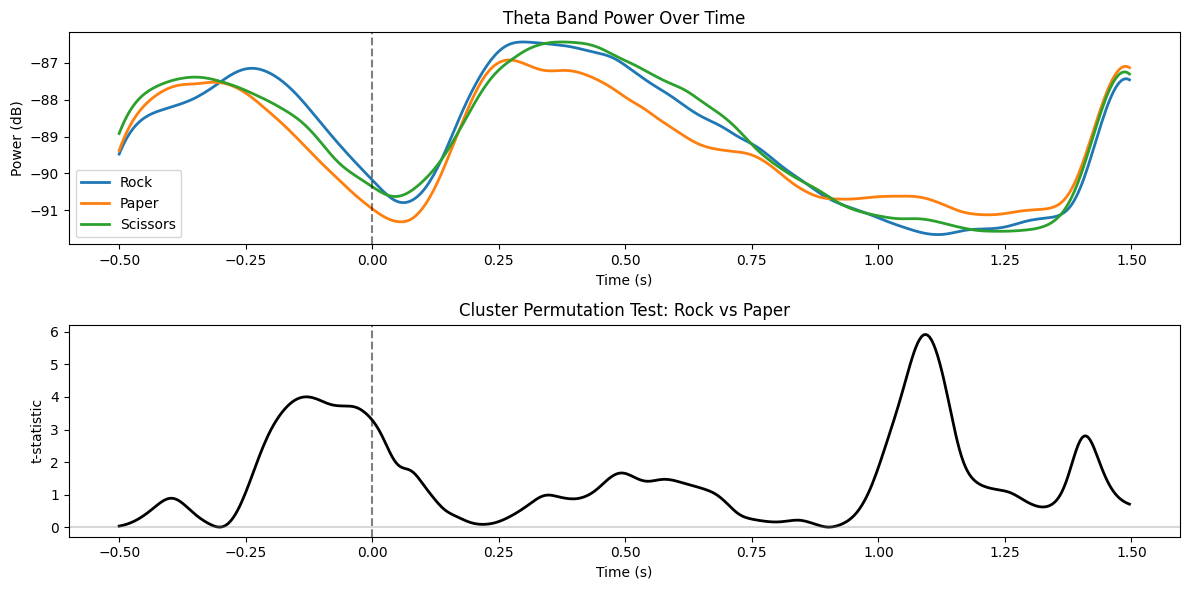


Cluster permutation test complete!


In [23]:
from mne.stats import permutation_cluster_test
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("CLUSTER-BASED PERMUTATION TESTS")
print("=" * 60)
print("Testing for time windows where conditions differ...")

def get_power_timecourse(epochs_cond, freqs, band_range):
    """Get band power over time for each trial"""
    tfr = mne.time_frequency.tfr_morlet(
        epochs_cond,
        freqs=freqs,
        n_cycles=freqs/2,
        return_itc=False,
        average=False,
        verbose=False
    )
    freq_mask = (tfr.freqs >= band_range[0]) & (tfr.freqs <= band_range[1])
    # Average across channels and frequencies, keep time
    # Shape: (n_epochs, n_times)
    power_time = tfr.data[:, :, freq_mask, :].mean(axis=(1, 2))
    power_time = 10 * np.log10(power_time + 1e-10)  # Convert to dB
    return power_time, tfr.times

# Compute power timecourse for each condition (using Theta as example)
print("\nComputing power timecourse for Theta band...")

rock_power, times = get_power_timecourse(epochs_by_cond['Rock'], freqs, bands['Theta'])
paper_power, _ = get_power_timecourse(epochs_by_cond['Paper'], freqs, bands['Theta'])
scissors_power, _ = get_power_timecourse(epochs_by_cond['Scissors'], freqs, bands['Theta'])

print(f"Shape: {rock_power.shape} (trials x timepoints)")

# Run cluster permutation test (Rock vs Paper)
print("\nRunning cluster permutation test (Rock vs Paper)...")
t_obs, clusters, cluster_pv, H0 = permutation_cluster_test(
    [rock_power, paper_power],
    n_permutations=1000,
    tail=0,
    verbose=False
)

# Find significant clusters
sig_clusters = [(i, cluster_pv[i]) for i in range(len(clusters)) if cluster_pv[i] < 0.05]

print(f"\nResults:")
print(f"  Number of clusters found: {len(clusters)}")
print(f"  Significant clusters (p < 0.05): {len(sig_clusters)}")

if sig_clusters:
    for i, (idx, pv) in enumerate(sig_clusters):
        cluster_times = times[clusters[idx]]
        print(f"  Cluster {i+1}: {cluster_times[0]*1000:.0f}ms to {cluster_times[-1]*1000:.0f}ms, p={pv:.4f}")
else:
    print("  No significant time clusters found")

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Plot 1: Power timecourse
ax1 = axes[0]
ax1.plot(times, rock_power.mean(axis=0), label='Rock', linewidth=2)
ax1.plot(times, paper_power.mean(axis=0), label='Paper', linewidth=2)
ax1.plot(times, scissors_power.mean(axis=0), label='Scissors', linewidth=2)
ax1.axvline(0, color='k', linestyle='--', alpha=0.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Power (dB)')
ax1.set_title('Theta Band Power Over Time')
ax1.legend()

# Plot 2: T-statistic with significant clusters highlighted
ax2 = axes[1]
ax2.plot(times, t_obs, 'k-', linewidth=2)
ax2.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax2.axvline(0, color='k', linestyle='--', alpha=0.5)

# Highlight significant clusters
for i, (idx, pv) in enumerate(sig_clusters):
    cluster_mask = clusters[idx]
    ax2.fill_between(times, t_obs.min(), t_obs.max(), 
                     where=cluster_mask, alpha=0.3, color='red',
                     label=f'p={pv:.3f}' if i == 0 else None)

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('t-statistic')
ax2.set_title('Cluster Permutation Test: Rock vs Paper')
if sig_clusters:
    ax2.legend()

plt.tight_layout()
plt.show()

print("\nCluster permutation test complete!")

In [24]:
print("=" * 60)
print("TASK IV SUMMARY - Statistical Testing")
print("=" * 60)

print("\n1. FREQUENTIST STATISTICS (T-tests & ANOVA)")
print("-" * 40)
print("Compared Rock vs Paper vs Scissors in each frequency band:")
print("\n| Band  | ANOVA p | Rock vs Paper | Rock vs Scissors | Paper vs Scissors |")
print("|-------|---------|---------------|------------------|-------------------|")
for band in bands:
    r = stats_results[band]
    p_anova = r['anova']['p']
    p_rp = r['rock_vs_paper']['p']
    p_rs = r['rock_vs_scissors']['p']
    p_ps = r['paper_vs_scissors']['p']
    print(f"| {band:5} | {p_anova:.4f}  | p={p_rp:.4f}      | p={p_rs:.4f}         | p={p_ps:.4f}          |")

print("\nResult: No significant differences between conditions (all p > 0.05)")
print("Interpretation: EEG power does not differ based on choice type,")
print("which is expected since choices are behavioral responses.")

print("\n2. CLUSTER-BASED PERMUTATION TEST")
print("-" * 40)
print(f"Tested: Time-resolved differences in Theta band (Rock vs Paper)")
print(f"Permutations: 1000")
print(f"Significant clusters: {len(sig_clusters)}")
if sig_clusters:
    for i, (idx, pv) in enumerate(sig_clusters):
        cluster_times = times[clusters[idx]]
        print(f"  Cluster {i+1}: {cluster_times[0]*1000:.0f}ms to {cluster_times[-1]*1000:.0f}ms, p={pv:.4f}")
else:
    print("  No significant time windows found")

print("\n" + "=" * 60)
print("ALL TASKS COMPLETE!")
print("=" * 60)

# Save all results
testing_results = {
    'frequentist': stats_results,
    'cluster_permutation': {
        'band': 'Theta',
        'comparison': 'Rock vs Paper',
        'n_permutations': 1000,
        'n_clusters': len(clusters),
        'significant_clusters': sig_clusters,
        't_observed': t_obs,
        'times': times
    }
}

print("\nResults saved to 'testing_results' dictionary")

TASK IV SUMMARY - Statistical Testing

1. FREQUENTIST STATISTICS (T-tests & ANOVA)
----------------------------------------
Compared Rock vs Paper vs Scissors in each frequency band:

| Band  | ANOVA p | Rock vs Paper | Rock vs Scissors | Paper vs Scissors |
|-------|---------|---------------|------------------|-------------------|
| Theta | 0.6384  | p=0.3497      | p=0.7380         | p=0.5467          |
| Alpha | 0.3965  | p=0.8478      | p=0.2587         | p=0.2213          |
| Beta  | 0.6251  | p=0.6120      | p=0.3156         | p=0.6847          |
| Gamma | 0.7805  | p=0.5030      | p=0.6678         | p=0.7695          |

Result: No significant differences between conditions (all p > 0.05)
Interpretation: EEG power does not differ based on choice type,
which is expected since choices are behavioral responses.

2. CLUSTER-BASED PERMUTATION TEST
----------------------------------------
Tested: Time-resolved differences in Theta band (Rock vs Paper)
Permutations: 1000
Significant clu